## Employee Org Salary Prediction
You are an HR, who is going to offer CTC to an employee, to make right negotiation you want to predict the salary, he is earning in current/previous org.<br>
We use dataset having designation and level of employee to predict the salary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Position_Salaries.csv')
data.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


Position and level are redundant columns, analyst, consultant means level 1, 2 only. So no need to use Position column in training.

In [5]:
# Get features and target
X = data.iloc[:, 1:-1].values
Y = data.iloc[:, -1].values

print(X)
print(Y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


### Checking Missing Data

In [4]:
print(data.isnull().sum())

Position    0
Level       0
Salary      0
dtype: int64


### Training Linear regression Model on complete dataset

In [6]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X,Y)

LinearRegression()

### Training polynomial regression on complete dataset

In [7]:
# Create feature matrix of powered features - x^1, x^2, x2^1, x2^2 ...
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
print(X_poly)

[[  1.   1.   1.]
 [  1.   2.   4.]
 [  1.   3.   9.]
 [  1.   4.  16.]
 [  1.   5.  25.]
 [  1.   6.  36.]
 [  1.   7.  49.]
 [  1.   8.  64.]
 [  1.   9.  81.]
 [  1.  10. 100.]]


In [8]:
# Now we train Linear regression model on X_poly dataset
model2 = LinearRegression()
model2.fit(X_poly, Y)

LinearRegression()

### Visualize Linear regression results

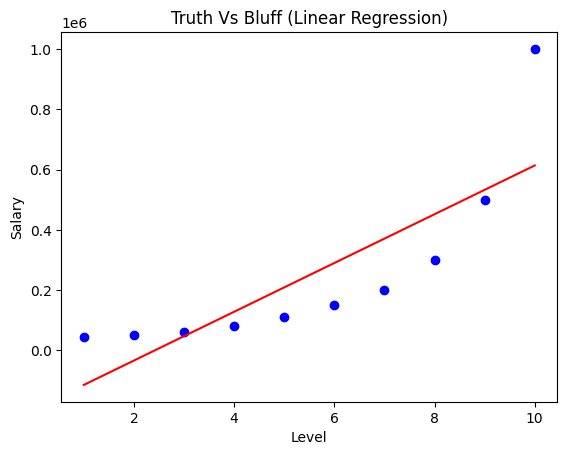

In [11]:
plt.scatter(X, Y, color='blue')
plt.plot(X, model1.predict(X), color='red')  # to create regression line
plt.xlabel('Level')
plt.ylabel('Salary')
plt.title('Truth Vs Bluff (Linear Regression)')
plt.show()

### Visualize polynomial regression results

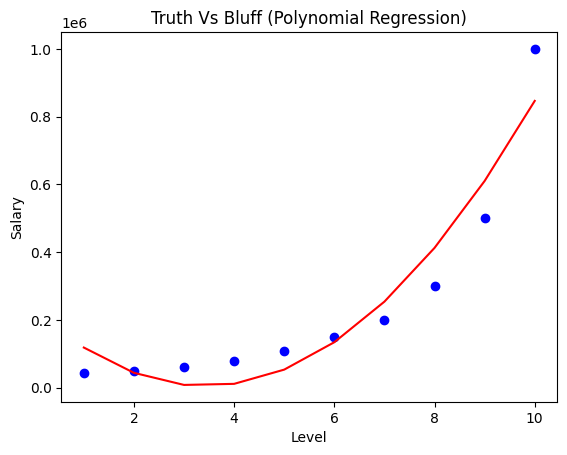

In [13]:
plt.scatter(X, Y, color='blue')
plt.plot(X, model2.predict(X_poly), color='red')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.title('Truth Vs Bluff (Polynomial Regression)')
plt.show()

Note- With higher degree of n, we may get more better results

### Predicting a new result with Linear Regression

### Predicting a new result with Polynomial Regression